# Multimodal Music Analysis

**Ομάδα:**
- Αθανάσιος Νικολέτας [sdi2300140]
- Αχιλλέας Πετροπουλάκης [sdi2300171]


## Installing dependances

In [1]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install scikit-learn
%pip install nltk
%pip install gensim
%pip install wordcloud
%pip install vaderSentiment
%pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached sentence_transformers-5.4.1-py3-none-any.whl.metadata (17 kB)
  Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached cuda_toolkit-13.0.2-py2.py3-none-any.whl.metadata (9.4 kB)
  Using cached cuda_bindings-13.2.0-cp312-c

## Loading the files and extracting data

In [39]:
import pandas as pd
import os

os.makedirs('../data/processed', exist_ok=True)

id_genres = pd.read_csv('../data/raw/id_genres.csv',sep='\t')
id_information = pd.read_csv('../data/raw/id_information.csv',sep='\t')
id_tags = pd.read_csv('../data/raw/id_tags.csv',sep='\t')


In [40]:
id_mfcc_stats = pd.read_csv('../data/raw/id_mfcc_stats.tsv.bz2',sep='\t',compression='bz2')

## Extract processed_lyrics from a tar.gz and creating processed_lyrics dictionary

For each file:

- get song_id from the filename
- read lyrics
- store to dictionary

make a dataframe using the dictionary

In [41]:
import tarfile
from pathlib import Path

processed_lyrics_dict = {}
with tarfile.open('../data/raw/processed_lyrics.tar.gz', 'r:gz') as tar:
    for member in tar.getmembers():
        if member.isfile():
            file = tar.extractfile(member)
            song_id = Path(member.name).stem
            processed_lyrics_dict[song_id] = file.read().decode('utf-8')

processed_lyrics = pd.DataFrame(
    list(processed_lyrics_dict.items()),
    columns=['id', 'lyrics']
)

processed_lyrics

,id,lyrics
0,9jbSytob9XRzwvB6,deep feel heart burn deep insid yearn know com...
1,Njp6JPM8vitbhVJU,noth hurt like pain someon love noth gain prep...
2,h48f46ZsT9h0Z5Dm,arm side heart sleev chandeli fall stand under...
3,kVtduoU5M56Amw1M,ladi ladi ladi ladi power ladi ladi ladi ladi ...
4,ZmXVK43zlqdeq6z8,end see face recogn thing must left behind pro...
...,...,...
109264,YgII1tHAaAnh14Kf,
109265,5fU9VEvtc2T1J11g,whole town line outsid tent kid think see real...
109266,76qenAf8gYlH4pfq,see store one day think may make play futur mu...
109267,9F8jQjeibAuZinEP,close right sand stretch like child night trus...


## Helper Functions

In [42]:


"""
function that explodes a comma-separated (to_explode) column
into multiple rows (new_name column) and returns the new dataframe
with the new column. 
"""
def explode_df(df, to_explode, new_name):
    df = df.copy()
    return df.assign(**{new_name: df[to_explode].str.split(',')}).explode(new_name)


""" 
function that cleans a scpecific column:
    - Replace '-' with space
    - Strip whitespace
    - Remove duplicates
    - returns clean dataframe
"""
def clean_df(df, to_clean):
    df = df.copy()
    df[to_clean] = df[to_clean].apply(
        lambda x: ','.join(dict.fromkeys(
            t.strip() for t in x.replace("-", " ").split(',')
        ))
    )
    return df

"""
function that finds top-N most frequent values
in a comma-separated column and returns value 
count df,top N list values and their frequency.
"""
def find_top_n(df, to_find, n):
    exploded = explode_df(df, to_find, "temp")
    result = exploded["temp"].value_counts().head(n).reset_index()
    result.columns = [to_find, 'count']
    topn_list = result[to_find].tolist()
    list_counts = result['count'].tolist()
    return result, topn_list, list_counts

"""
function that finds if there is at least
a value in a comma-separated column 
that matches with values and returns
filtered data frame.
"""
def find_in_list(df, to_find, values):
    values = set(values)
    mask = df[to_find].apply(
        lambda x: any(val.strip() in values for val in x.split(','))
    )
    return df[mask]

""" 
function that selects the first matching
value with values from a comma-separated
column and returns the df with the new column(new_name).    
"""
def find_primary(df, to_find, values, new_name):
    def first_match(column_val):
        for val in column_val.split(','):
            if val.strip() in values:
                return val.strip()
        return None
    df = df.copy()
    df[new_name] = df[to_find].apply(first_match)
    return df

"""
function that prints information about
the final dataset.
"""
def print_info(top5_data_frame,final):
    print("~Top 5 genres with song count~")
    print(top5_data_frame)
    print("\nshape:", final.shape)
    print("\nfinal_dataframe with columns με στήλες: id, genre, lyrics, mfcc_stats")
    print(final.head())
    print("\ninfo")
    final.info()

"""
function that converts dataframe into 
dictionary mapping.
"""
def df_to_dict(df,keys,values):
    return df.set_index(keys)[values].to_dict()

    

## Filtering 

We clean , find top 5 genres and then based on those we merge to a final dataframe, the chosen_id_genres the processed_lyrics and id_mfcc_stats on id.


In [43]:
# cleaning dataframe. Remove duplicates and - 
id_tags    = clean_df(df=id_tags,to_clean="tags")
id_genres  = clean_df(df=id_genres,to_clean="genres")

# find top-5 genres based on their frequency and how many songs each genre has
top5_data_frame,top5_list,top5_counts = find_top_n(df=id_genres,
                                                   to_find="genres",
                                                   n=5)
# find ids that belong to top-5 genres
chosen_id_genres = find_in_list(df=id_genres, 
                                to_find='genres', 
                                values=top5_list).drop_duplicates(subset='id')

# merge lyrics and stats with chosen_ids that belong to top-5 genres and take a sample  
final = chosen_id_genres.merge(processed_lyrics, on='id', how='inner').merge(id_mfcc_stats, on='id', how='inner')
final = final.sample(n=7500, random_state=42).reset_index(drop=True)
final.to_csv('../data/processed/final_dataset.csv', index=False)

print_info(top5_data_frame=top5_data_frame,final=final)


~Top 5 genres with song count~
             genres  count
0              rock  23949
1               pop  20267
2        electronic  11739
3  alternative rock   7591
4        indie rock   7353

shape: (7500, 107)

final_dataframe with columns με στήλες: id, genre, lyrics, mfcc_stats
                 id                                   genres  \
0  rCBwys9UDbrFaqnx  rock,singer songwriter,classic rock,pop   
1  jwJo2kvKA2Gu3ftS       classic rock,rock,progressive rock   
2  bMnqQtrkYjnsrxnp              post hardcore,pop,metalcore   
3  ToVL2QCrrhcqq6Uc                               indie rock   
4  0U91aHvEcuFKaBD1                      folk,indie rock,emo   

                                              lyrics    MFCC000    MFCC001  \
0  well tell everyon disgrac drag name place care...  22.468723  10.656616   
1  close eye moment moment go dream pass eye curi...  22.296486   3.688473   
2  mad give want never feel feel call love call n...  20.657087  -4.007842   
3  hey babi look wa

## Text Embeddings

We preprocess the lyrics by cleaning the text, including lowercasing, removal of non-alphabetic characters, stopword removal, and lemmatization.

Then we train a Word2Vec model using the tokenized lyrics, in order to learn vector representations for each word based on its context.

Finally we compute the average of all word vectors in the song to get a vector for the whole song

In [44]:
import re
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english')) 
lemmatizer = WordNetLemmatizer()

""" 
function that returns list of cleaned
and lemmatized tokens
"""
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # we use only letters and spaces

    tokens = word_tokenize(text) # text to words

    tokens = [word for word in tokens if word not in stop_words] # stop_words removal
    tokens = [lemmatizer.lemmatize(word) for word in tokens] # lemmatization

    return tokens


final = final.copy()
final['tokens'] = final['lyrics'].apply(clean_text)

from gensim.models import Word2Vec

# vector for every word
w2v_model = Word2Vec(
    sentences=final['tokens'].tolist(),
    vector_size=200, # desired no. of features/independent variables
    window=5, # context window size
    min_count=2,
    sg = 1, # 1 for skip-gram model
    hs = 0,
    negative = 10, # for negative sampling
    workers= 2, # no.of cores
    seed = 34
)

"""
function that makes one vector using mean
for the whole song from all word vectors
and returns it
"""
def get_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv] 

    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

# convert each song into a vector using mean
text_embeddings = np.array([
    get_embedding(song, w2v_model)
    for song in final['tokens']
])

print(text_embeddings.shape)

[nltk_data] Downloading package punkt to /home/thanos/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/thanos/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/thanos/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


(7500, 200)


## Text Embeddings. Bonus (BERT)

- Instead of Word2Vec, we use a pre-trained sentence-transformer model all-MiniLM-L6-v2.

- This model reads the entire lyric at once and produces a single 384-dimensional vector that captures the overall meaning

- Because it was pre-trained on diverse texts, it understands language better than Word2Vec


In [45]:
from sentence_transformers import SentenceTransformer

bert_model = SentenceTransformer('all-MiniLM-L6-v2')

text_embeddings_bert = bert_model.encode(
    final['lyrics'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
)

print("BERT text embeddings shape:", text_embeddings_bert.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/235 [00:00<?, ?it/s]

BERT text embeddings shape: (7500, 384)


## Audio Ebbendings

The audio features consist of high-dimensional MFCC statistics, which result in large and noisy vectors.

To make them easier to use, we first standardize the features and then apply PCA.

This reduces the dimensionality of the data while preserving 95% of the total variance resulting in more meaningful audio embeddings.

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# take mfcc and cov_ columns
mfcc_cols = [c for c in final.columns if c.startswith('MFCC') or c.startswith('cov_')] 
audio_features = final[mfcc_cols].values # making the matrix

# put all features on the same scale
scaler = StandardScaler()
audio_scaled = scaler.fit_transform(audio_features)

# keep 95% of the information
pca = PCA(n_components=0.95)
audio_embeddings = pca.fit_transform(audio_scaled)

print("Dimensions before changing: ",audio_features.shape[1])
print("After PCA (95% variance): ",audio_embeddings.shape[1])

Dimensions before changing:  104
After PCA (95% variance):  79


## Audio Embeddings. Bonus (Dense Autoencoder)

Instead of using PCA, we train a Dense Autoencoder to compress the MFCC statistics.

The autoencoder learns a compressed 32-dimensional representation by:
- Compressing: 104 MFCC dimensions -> 64 dimensions -> 32 dimensions (bottleneck)
- Reconstructing: 32 dimensions -> 64 dimensions → 104 dimensions

Once trained, we extract only the bottleneck layer and this becomes our audio embedding. 

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
import numpy as np

# take mfcc and cov_ columns
mfcc_cols = [col for col in final.columns if 'mfcc' in col.lower()]
audio_features = final[mfcc_cols].values  # making the matrix

# put all features on the same scale
scaler = StandardScaler()
audio_scaled = scaler.fit_transform(audio_features)

# train autoencoder
autoencoder = MLPRegressor(hidden_layer_sizes=(64, 32, 64), max_iter=200, random_state=42)
autoencoder.fit(audio_scaled, audio_scaled)  

# extract bottleneck embeddings (stop at layer 2 = 32 dims)
audio_input = audio_scaled

# layer 1: apply ReLU activation
hidden_layer_1 = np.maximum(
    np.dot(audio_input, autoencoder.coefs_[0]) + autoencoder.intercepts_[0], 
    0
)
#layer 2: apply ReLU activation
audio_embeddings_autoencoder = np.maximum(
    np.dot(hidden_layer_1, autoencoder.coefs_[1]) + autoencoder.intercepts_[1], 
    0
)

print(audio_embeddings_autoencoder.shape) 


(7500, 32)


## Word Clouds

- We extract the tags (which are separated by commas) for the songs belonging to the selected genres, in our example rock and electronic which are completely different.

- We also count their frequency of each tag to make Word Clouds for each genre.

From Word Clouds, we can observe that these genres are significantly different in terms of thematic content,because in rock there are more traditional, powerful and intese themes and is often linked to earlier decades such as the 60s to 90s. thus in electronic there are more positive,energetic and trend themes which are more common from the 90s to the 2010s.

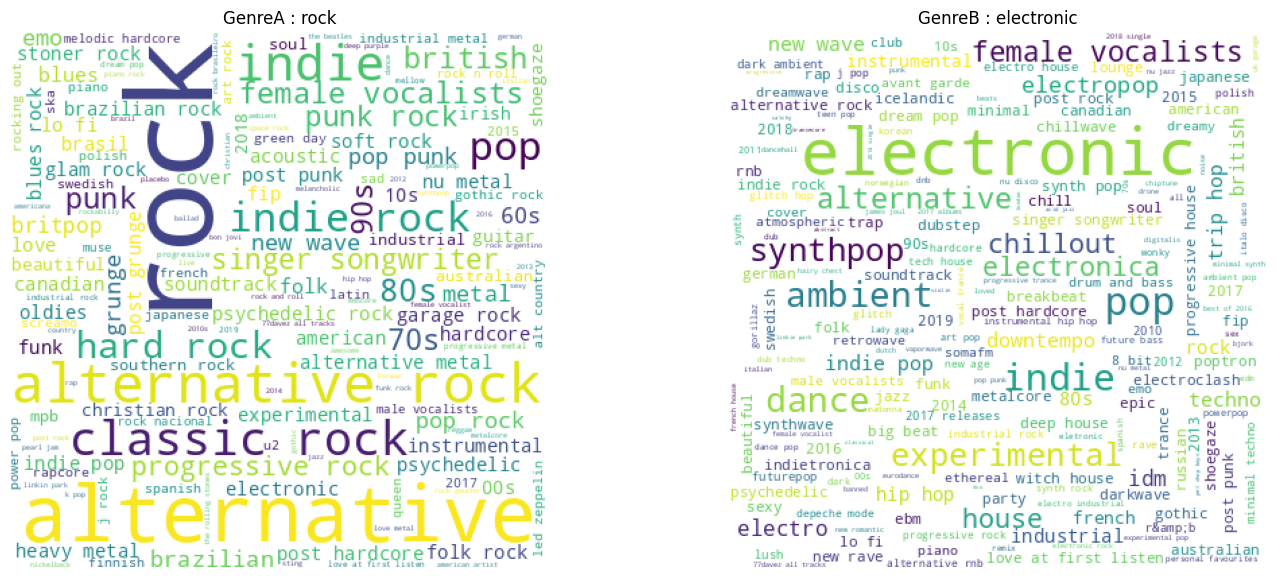

In [48]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# select rock and electronic from our top-5 list
genre_a, genre_b = top5_list[0], top5_list[2]

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for a, genre,i in zip(axes, [genre_a, genre_b],['A','B']):
    found_genre_ids = find_in_list(df=final,
                                   to_find="genres",
                                   values=[genre])['id'].unique()

    found_id_tags = find_in_list(df=id_tags,
                                 to_find="id",
                                 values=found_genre_ids.tolist())

    # rank all tags
    topn_data_frame, topn_list, topn_counts = find_top_n(df=found_id_tags,
                                                         to_find="tags",
                                                         n=found_id_tags.shape[0])
    # make dictionary for wc
    tag_freq= df_to_dict(df=topn_data_frame,
                         keys="tags",
                         values="count")

    wc = WordCloud(width=400, 
                   height=400, 
                   background_color='white').generate_from_frequencies(tag_freq)
    a.imshow(wc)
    a.set_title(f'Genre{i} : {genre}')
    a.axis('off')

plt.show()

## Bar Chart

- We find the most frequent tags for each of the top genres by first splitting the genre column and assigning each song to its corresponding genres.For each genre, we collect all song ids and extract their tags.

- Then we compute the frequency of each tag by splitting them.

- Finally, we visualize the top 10 most frequent tags per genre using horizontal bar charts.

From the charts we can observe the characteristics of each genre and their relatiionships between them. Μore specifically all genres except electronic have rock related tags since they are closely related with rock.Also rock, indie rock and alternative rock have more intense and traditional themes and share common tags, thus pop and electronic more modern,energetic and positive themes and have a bit different tags.

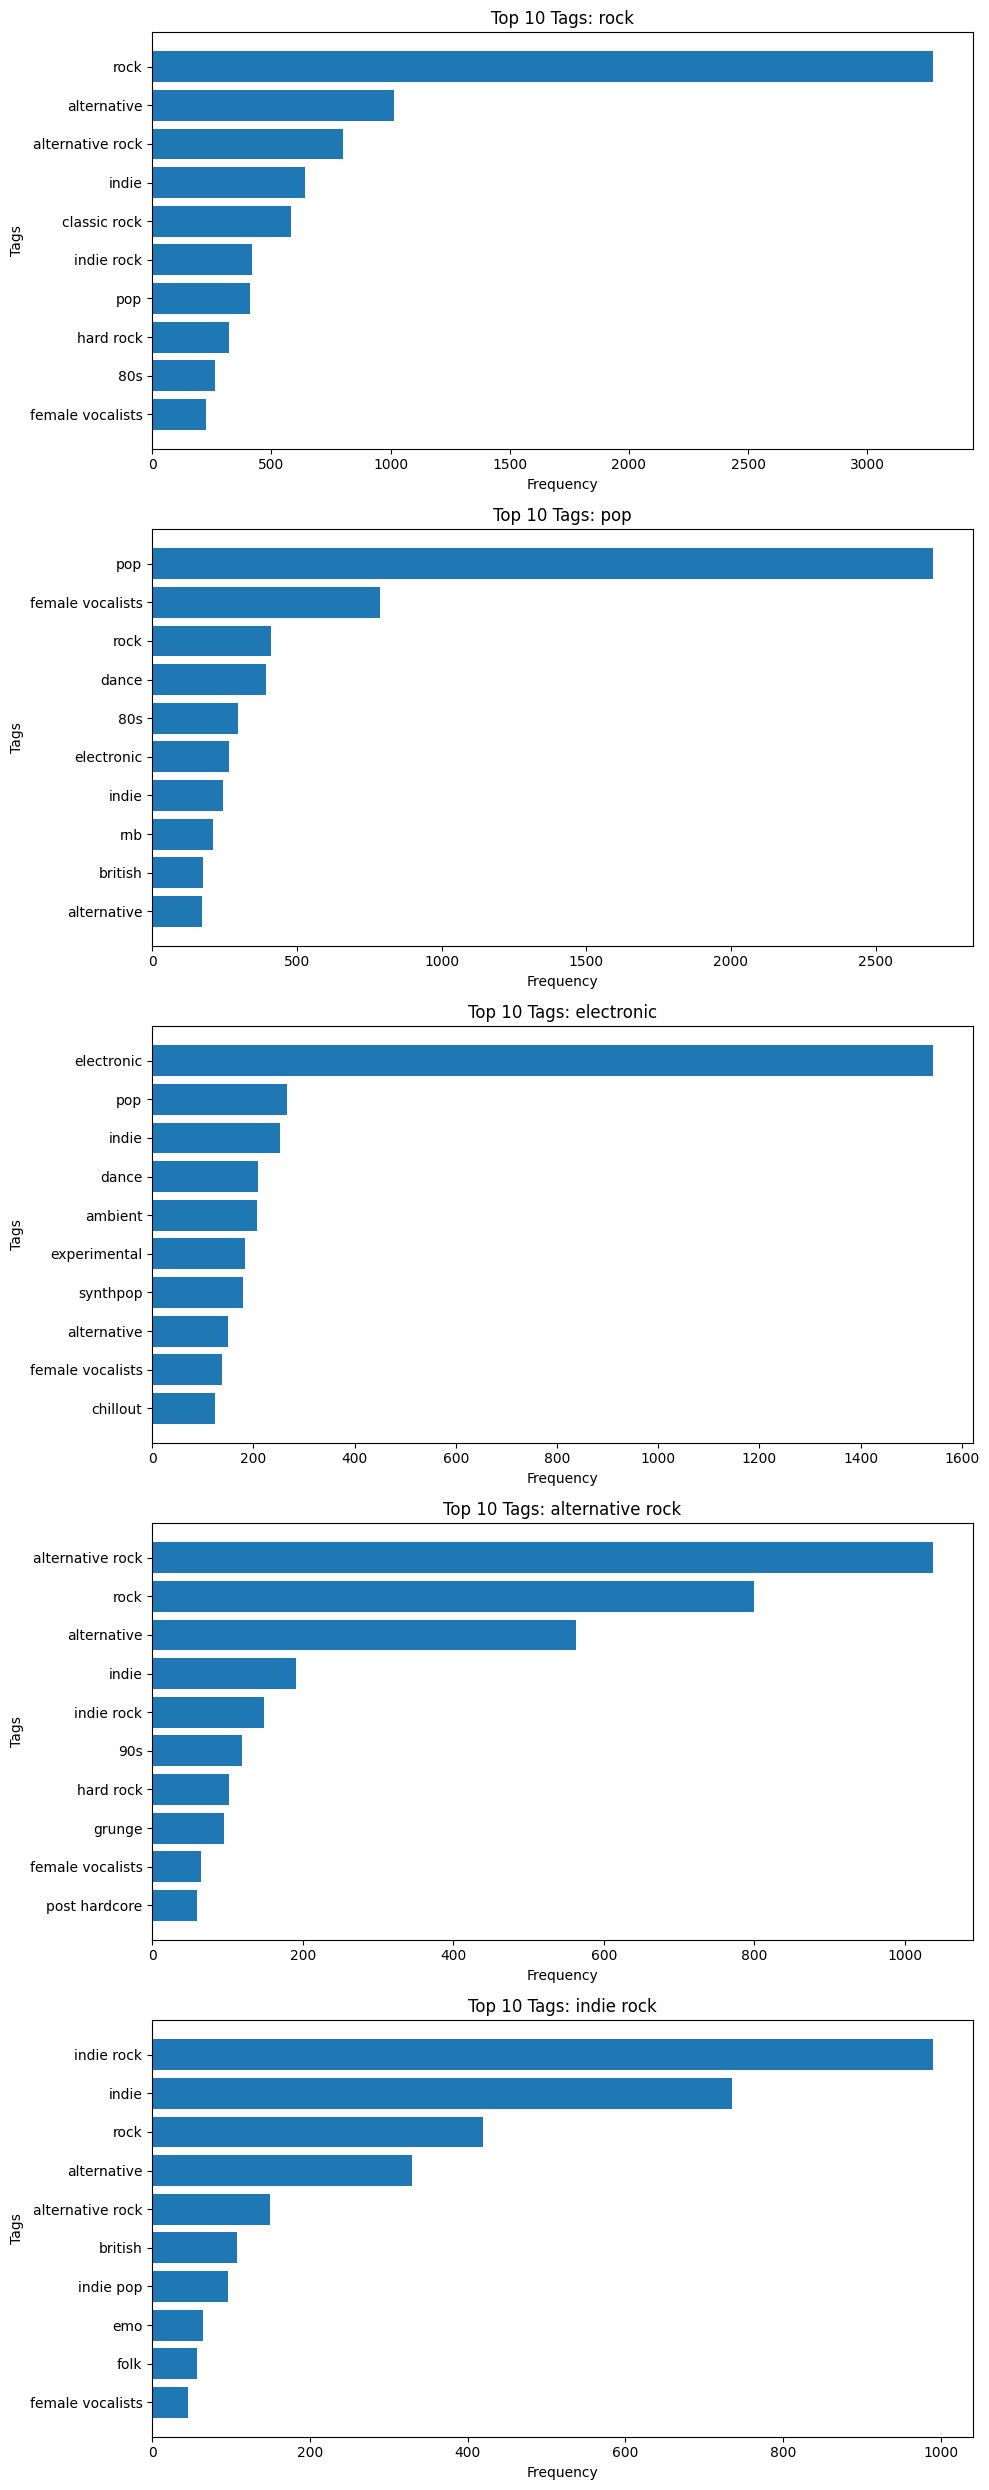

In [49]:
fig, axes = plt.subplots(len(top5_list), 1, figsize=(10, 5 * len(top5_list)))

for a, genre in zip(axes, top5_list):
    found_genre_ids = find_in_list(df=final,
                               to_find="genres",
                               values=[genre])['id'].unique()

    found_id_tags = find_in_list(df=id_tags,
                             to_find="id",
                             values=found_genre_ids.tolist())


    # rank tags and store top-10
    topn_data_frame, topn_list, topn_counts = find_top_n(df=found_id_tags,
                                                        to_find="tags",
                                                        n=10)

    a.barh(topn_list, topn_counts)
    a.invert_yaxis()
    a.set_title(f'Top 10 Tags: {genre}')
    a.set_xlabel("Frequency")
    a.set_ylabel("Tags")


plt.tight_layout()
plt.show()


## 2D Projections of Embeddings

- We apply PCA and t-SNE to both text and audio embeddings from bonus to project them into 2D space.Each song is colored by its primary genre, the first genre that belongs to the top-5.

- From the plots, we observe that t-SNE produces clearer clusters compared to PCA, as it captures non-linear relationships in the data.

Audio embeddings exhibit more distinct and separable clusters than text embeddings,since mfcc features capture acoustic properties that are related to musical style and genre. On the other hand lyrics can be shared from song to song regardless of the gerne they belong,which leads to higher overlap.

Despite these differences, in both plots clusters overlap,since rock has heavy impact to the rest of the genres so they can have similar lyrical and acoustic content.

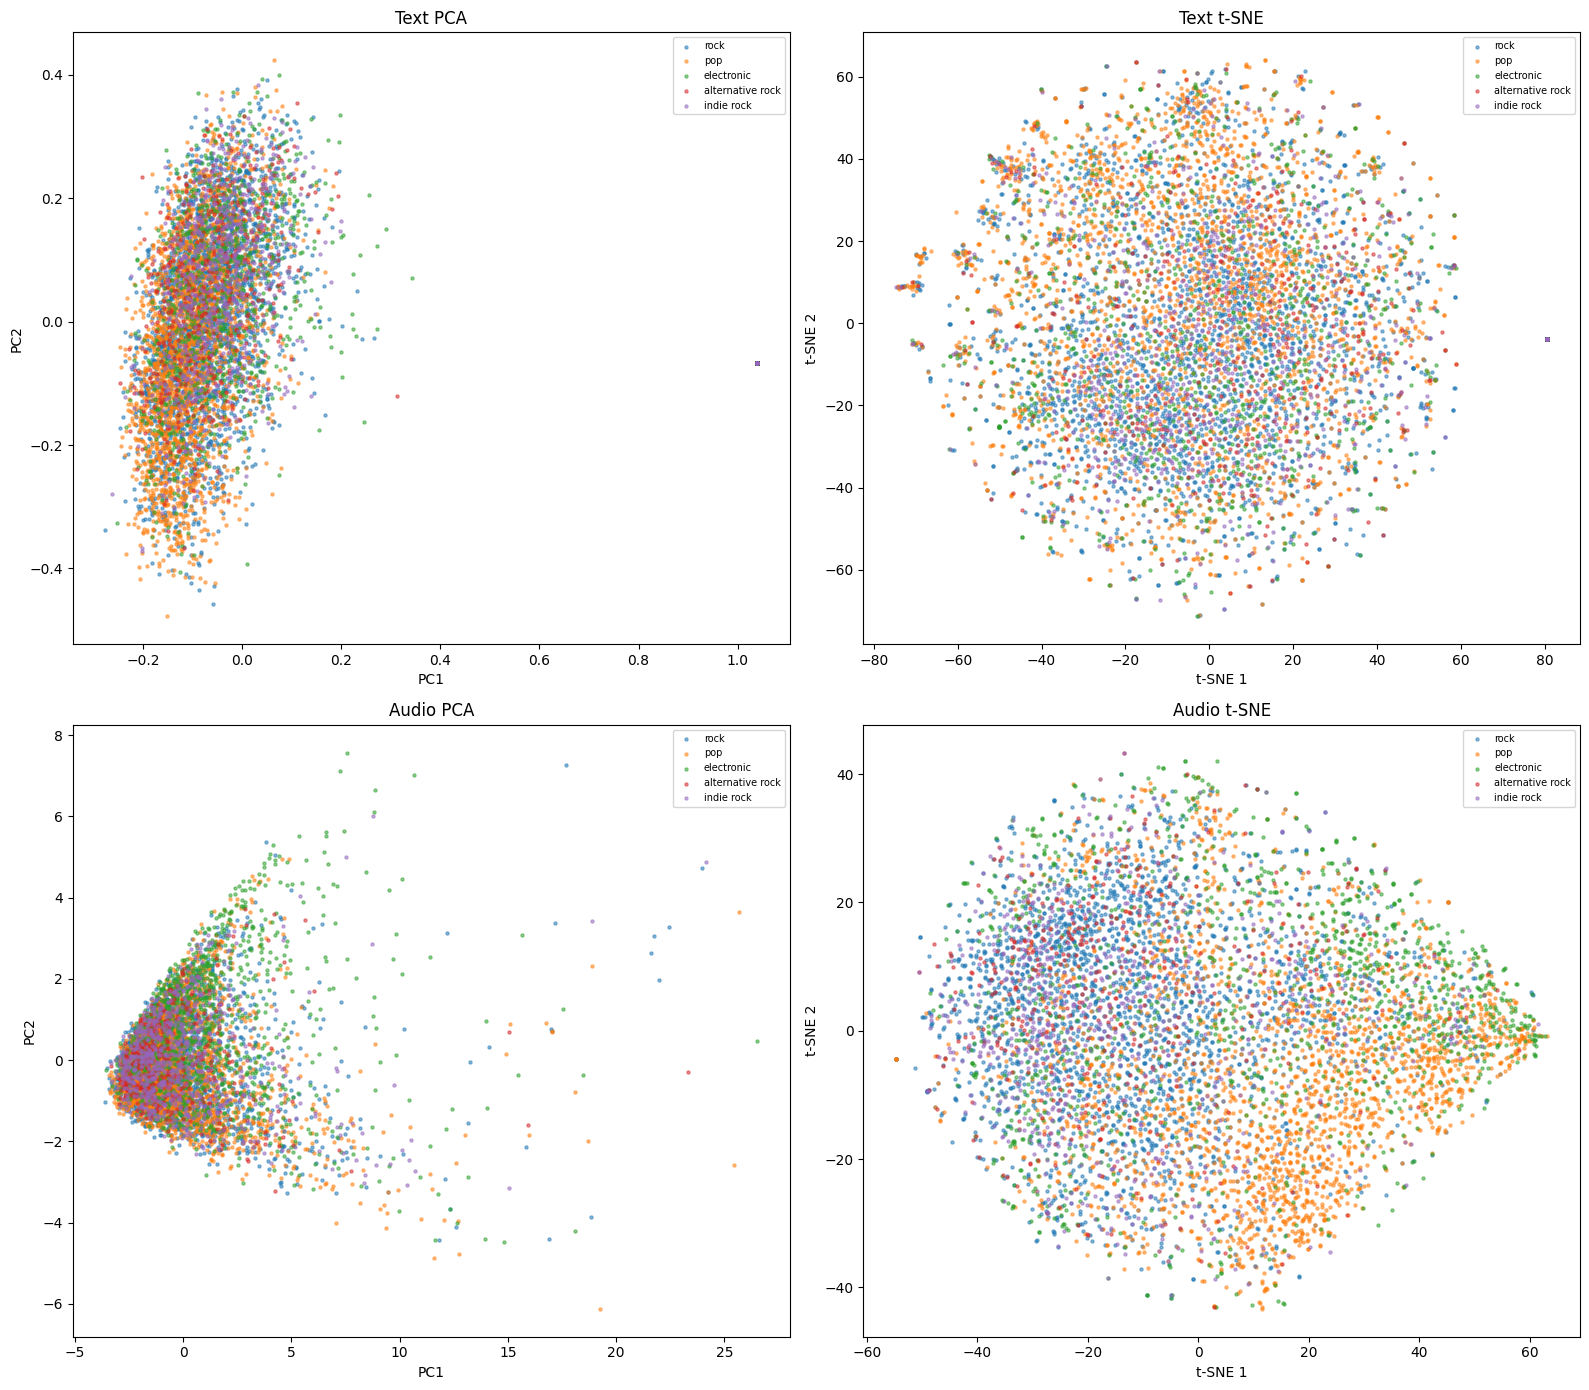

In [50]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# chose for every song one primary genre
final_primary = find_primary(df=final, to_find="genres", values=top5_list,new_name="primary genre")

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# text embeddings

# reduce text embeddings to 2D using PCA
text_2d_pca = PCA(n_components=2).fit_transform(text_embeddings_bert)

# reduce text embeddings to 2D using t-SNE
text_2d_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(text_embeddings)


# audio embeddings

# Reduce audio embeddings to 2D using PCA
audio_2d_pca = PCA(n_components=2).fit_transform(audio_embeddings_autoencoder)

# Reduce audio embeddings to 2D using t-SNE
audio_2d_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(audio_embeddings)

titles = ['Text PCA', 'Text t-SNE', 'Audio PCA', 'Audio t-SNE']
data = [text_2d_pca, text_2d_tsne, audio_2d_pca, audio_2d_tsne]

for a, title, d in zip(axes.flat, titles, data):
    # plot each genre with different color
    for genre in top5_list:
        # filter for current genre
        mask = final_primary['primary genre'].values == genre
        a.scatter(d[mask, 0], d[mask, 1], label=genre, alpha=0.5, s=5)
        
    a.set_title(title)
    
    if "PCA" in title:
        a.set_xlabel("PC1")
        a.set_ylabel("PC2")
    else:
        a.set_xlabel("t-SNE 1")
        a.set_ylabel("t-SNE 2")
        
    a.legend(fontsize=7)

plt.tight_layout()
plt.show()


## Genre Count Distribution

The distribution of genre counts shows that most songs belong to 2 genres, followed by 3 genres, while single-genre songs are also common. Songs with 4 or more genres are relatively rare.

This means that the dataset has multiple genres per song and there is an overlap between genres, but most songs are associated with a small number of closely related genres.

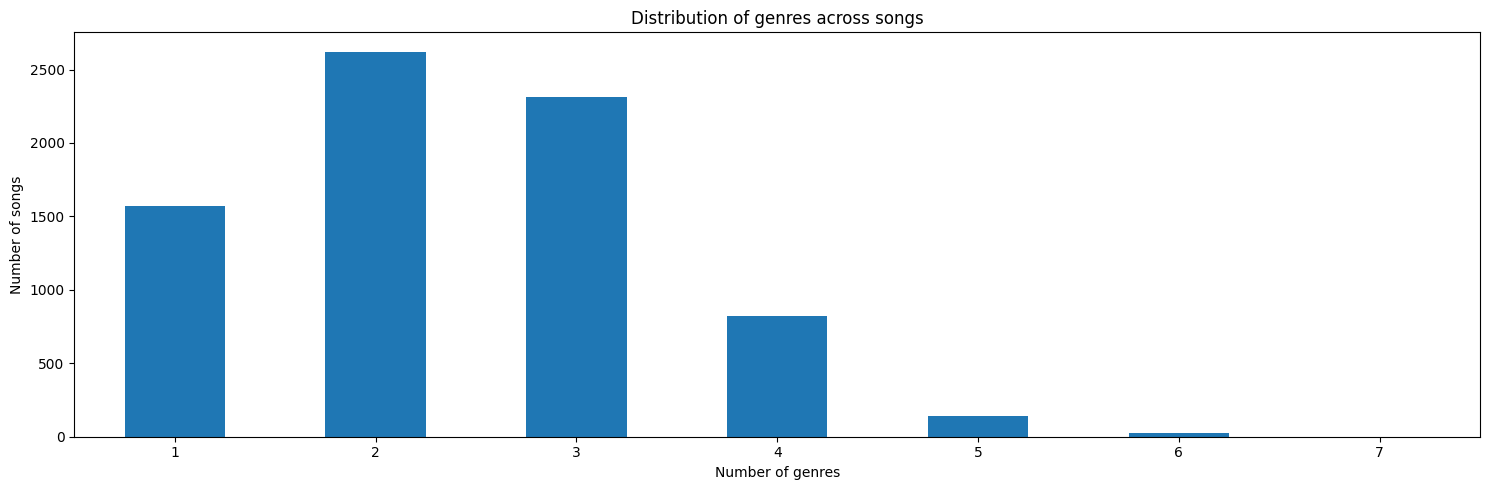

In [51]:
# count in how many genres each song belongs
final['genre_count'] = final['genres'].str.split(',').apply(len)

fig, a = plt.subplots(figsize=(15, 5))

# plot the distribution of genre counts across songs
final['genre_count'].value_counts().sort_index().plot(kind='bar', ax=a)

a.set_xlabel('Number of genres')
a.set_ylabel('Number of songs')
a.set_title('Distribution of genres across songs')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Top 10 Genres

- We identify the top 10 most frequent genres in the dataset. 

- Then, we compute how many songs belong to each of these genres.

From the plot we observe that rock and pop are the most dominant genres,because they are widely used categories that include many subgenres (alternative rock, indie rock, pop rock). As a result, most of the songs are assigned to these genres and they have higher overall frequency compared to more specific genres.

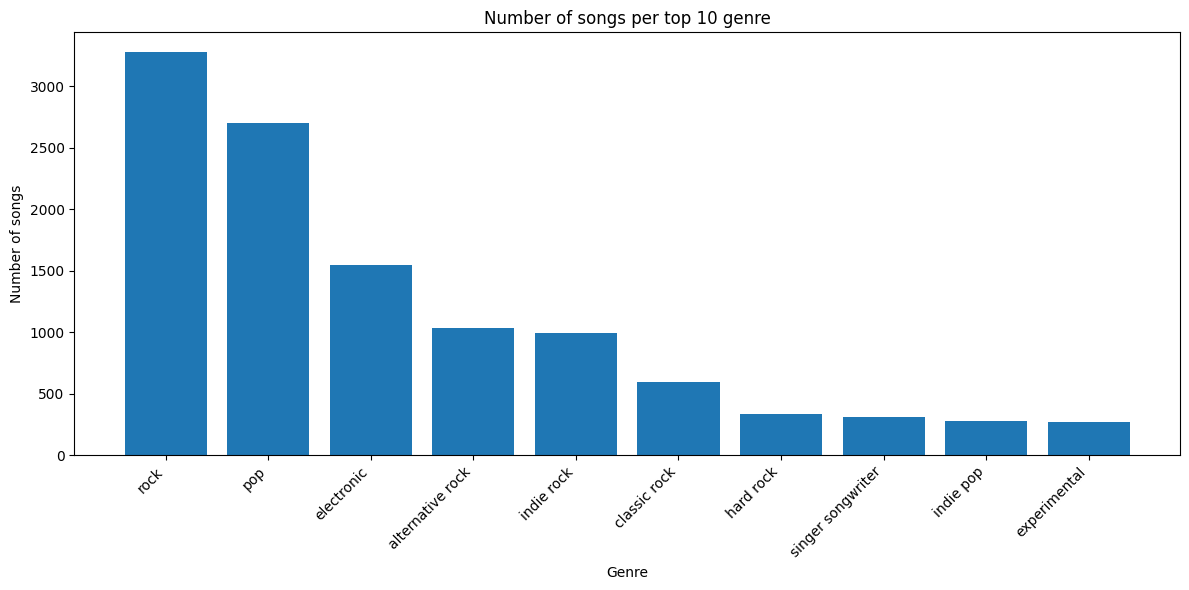

In [52]:
# find the top 10 most frequent genres and their song counts
top10_data_frame, top10_list, top10_counts = find_top_n(df=final,
                                                        to_find="genres",
                                                        n=10)


fig, a = plt.subplots(figsize=(12, 6))

a.bar(top10_list, top10_counts)
a.set_title('Number of songs per top 10 genre')
a.set_xlabel('Genre')
a.set_ylabel('Number of songs')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## The distribution of lyrics length

In terms of word count, most songs contain a moderate number of words, while few have long lyrics. This is also observed in character count, with most songs clustered in a mid-range but some extending to large lengths.

After removing stopwords, we compute the number of meaningful words per song. The average word count is approximately 108 words per song, while the average number of meaningful words is 107. Lyrics already consist mostly of meaningful words, and stopword removal has only a minor impact.

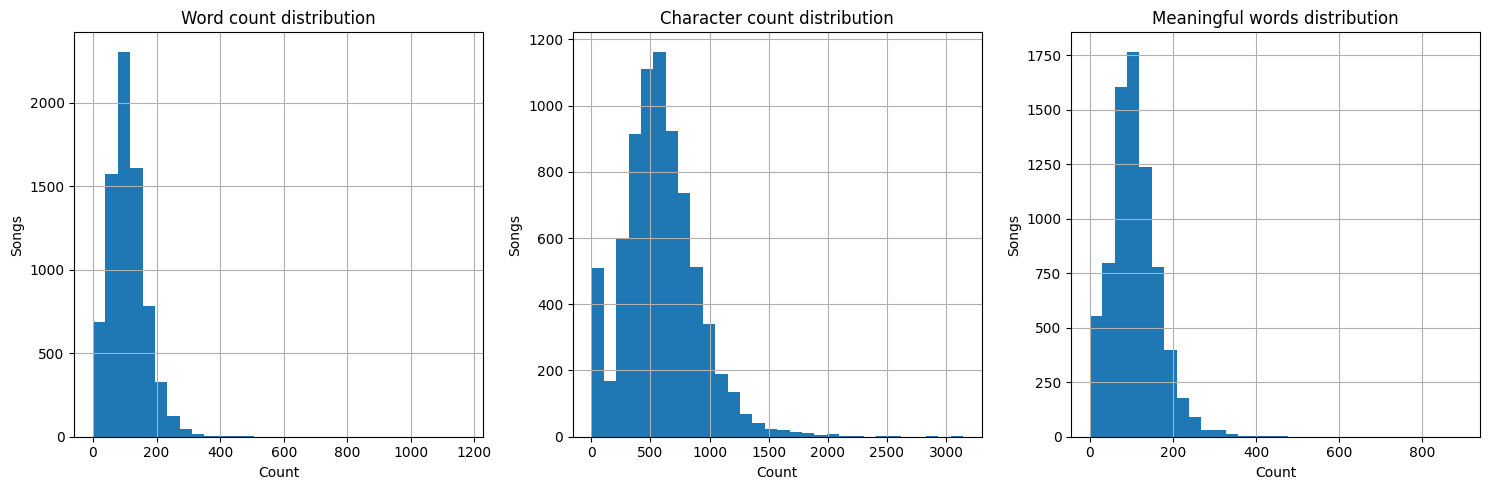

Avg words: 108, Avg meaningful: 107


In [53]:
# Count number of words for each song
final['word_count'] = final['lyrics'].str.split().apply(len)

# Count number of chars for each song
final['char_count'] = final['lyrics'].str.len()

# Count number of meaningful words for each song
final['meaningful_words'] = final['tokens'].apply(len)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

final['word_count'].hist(bins=30, ax=axes[0])
axes[0].set_title('Word count distribution')

final['char_count'].hist(bins=30, ax=axes[1])
axes[1].set_title('Character count distribution')

final['meaningful_words'].hist(bins=30, ax=axes[2])
axes[2].set_title('Meaningful words distribution')

for a in axes:
    a.set_ylabel('Songs')
    a.set_xlabel('Count')

plt.tight_layout()
plt.show()

print(f"Avg words: {final['word_count'].mean():.0f}, "
      f"Avg meaningful: {final['meaningful_words'].mean():.0f}")


## Sentiment Analysis per Genre

Using the pre-trained VADER sentiment analyzer, we compute a compound sentiment score for each song's lyrics (-1 = very negative, +1 = very positive).We then group the songs by their primary genre and compare the distributions 

Our plot shows us that songs have really positive lyrics but pop exceeds the mean and is the most positive related genre and the rest are less positve, with the least positive to be electronic which support our word cloud analysis that also concluded pop and electronic are completely diffrent genres.


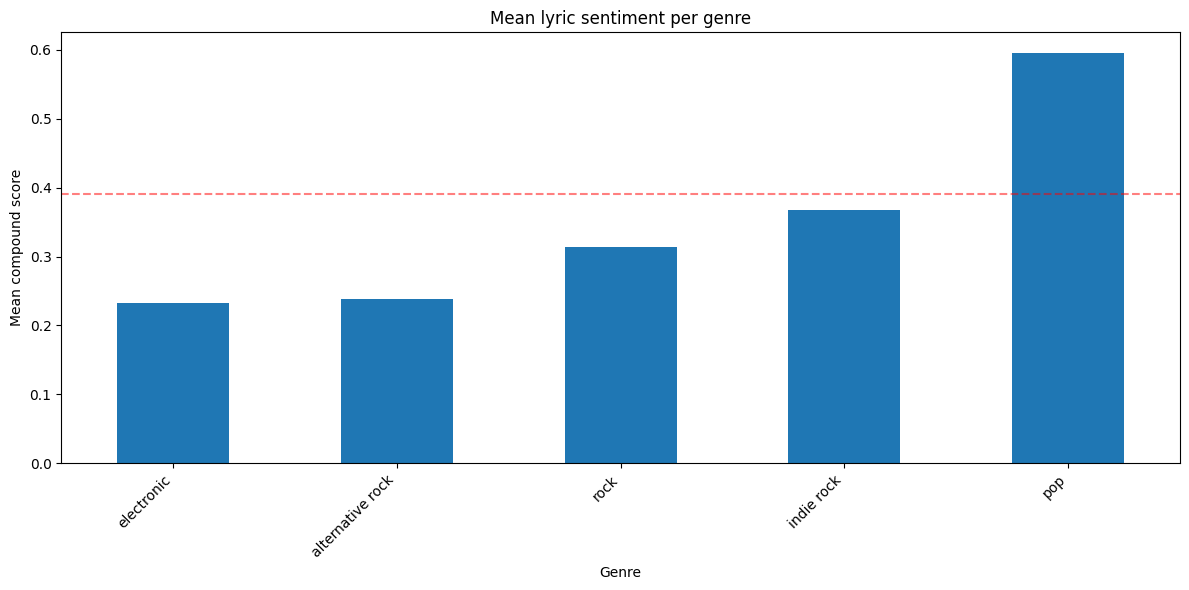

primary_genre
electronic          0.232163
alternative rock    0.238449
rock                0.314610
indie rock          0.367850
pop                 0.595641
Name: sentiment, dtype: float64

In [54]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Compute sentiment score for each song's lyrics
final['sentiment'] = final['lyrics'].apply(lambda t: analyzer.polarity_scores(t)['compound'])

# chose for every song one primary genre
final_primary = find_primary(df=final, to_find="genres", values=top5_list, new_name="primary_genre")

# Compute average sentiment for each genre
mean_sentiment = final_primary.groupby('primary_genre')['sentiment'].mean().sort_values()

fig, a = plt.subplots(figsize=(12, 6))

mean_sentiment.plot(kind='bar', ax=a)

a.axhline(final['sentiment'].mean(), color='red', linestyle='--', alpha=0.5)
a.set_title('Mean lyric sentiment per genre')
a.set_xlabel('Genre')
a.set_ylabel('Mean compound score')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

mean_sentiment.describe()
mean_sentiment


## Similarity Analysis

We use cosine similarity to find the 5 most similar songs to a query song, based on lyric embeddings and audio embeddings separately.

- Lyric-based similarity: Songs tend to have very high scores, indicating similar lyrics and themes and capturing semantic meaning. Most belong to related genres such as rock and indie rock.

- Audio-based similarity: Songs tend to have lower scores, with more diverse genres. This suggests audio embeddings capture rhythm and energy rather than exact genre matches.


In [55]:
from sklearn.metrics.pairwise import cosine_similarity

def top5_similar(query_idx, embeddings):
    sims = cosine_similarity([embeddings[query_idx]], embeddings)[0]
    return sims.argsort()[-6:-1][::-1], sims

sample_idx = 0
print(f"query: {final.iloc[sample_idx]['id']} - genre: {final.iloc[sample_idx]['genres']}\n")

text_top5, text_sim = top5_similar(sample_idx, text_embeddings_bert)
print("top 5 similar by lyrics:")
for i in text_top5:
    print(f"    {final.iloc[i]['id']} - {final.iloc[i]['genres']} - sim: {text_sim[i]}")

audio_top5, audio_sim = top5_similar(sample_idx, audio_embeddings_autoencoder)
print("\ntop 5 similar by audio:")
for i in audio_top5:
    print(f"    {final.iloc[i]['id']} - {final.iloc[i]['genres']} - sim: {audio_sim[i]}")



query: rCBwys9UDbrFaqnx - genre: rock,singer songwriter,classic rock,pop

top 5 similar by lyrics:
    7PCTOXUwR2lO6jQy - pop - sim: 0.7086961269378662
    fFolIThFvGWL5bgS - indie rock,emo,country - sim: 0.7032119035720825
    9RSBSiPBKRbAFSFo - rock,grunge,indie rock - sim: 0.6966832280158997
    sRR2tX3ilC3YYocz - folk,rock,classic rock,folk rock - sim: 0.6888543367385864
    SCOIiVtpfg4U9DuQ - pop,latin pop,electronica - sim: 0.6873160600662231

top 5 similar by audio:
    XavQ6pNvqEU5xoFV - soul,pop - sim: 0.9893606749064627
    jNYwJjowWYkuhD9P - rock,progressive rock,classic rock - sim: 0.9764259814490851
    OPfLbWfPG6JUZq16 - experimental,electronic - sim: 0.9762644001501986
    xVLnf3h6w2nIXWaL - classic rock,rock - sim: 0.9740110109030066
    o79hHHGLwt74QlTK - indie rock,rock - sim: 0.9726985753249366


# PART B: Classification, Fusion and Evaluation

In Part B we use the embeddings produced in Part A in order to:
- train two unimodal classifiers (text-only, audio-only) for **Genre Classification**
- combine the two modalities with **Early** and **Late Fusion**
- evaluate all approaches with **10-fold Cross Validation** and report Accuracy, Precision, Recall and F1-score (macro)
- apply **K-Means** on the fused vector and compare the resulting clusters with the actual genre labels via the **Adjusted Rand Index**

As labels we use the **primary genre** of every song (the first genre that appears in the top-5 list — same definition used in the EDA of Part A).

In [ ]:
from sklearn.preprocessing import LabelEncoder

# keep only the songs that have a valid primary genre (= belong to the top-5 list)
final_primary = find_primary(df=final, to_find="genres",
                             values=top5_list, new_name="primary_genre")
mask = final_primary['primary_genre'].notna().values

# X for text and audio - we use the BERT and PCA embeddings produced in Part A
X_text  = text_embeddings_bert[mask]
X_audio = audio_embeddings[mask]

# label-encode the primary genre into integers 0..4
le = LabelEncoder()
y  = le.fit_transform(final_primary.loc[mask, 'primary_genre'].values)

print("Text embeddings: ", X_text.shape)
print("Audio embeddings:", X_audio.shape)
print("Labels:          ", y.shape, "| classes:", list(le.classes_))

## Unimodal Classifiers (Model A & Model B)

We train a Logistic Regression classifier for each modality:
- **Model A**: takes as input only the Text embeddings (BERT, 384-dim)
- **Model B**: takes as input only the Audio embeddings (PCA, 95% variance)

We chose Logistic Regression because:
- it is fast on high-dimensional dense embeddings
- it provides probabilistic outputs (`predict_proba`) which we will need for Late Fusion
- it works well as a strong linear baseline on dense vector representations

For every model we run a 10-fold **Stratified** Cross-Validation (so each fold has the same genre distribution) and report Accuracy, Precision, Recall and F1-score (macro-averaged, so all classes have equal weight regardless of size).

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

# Stratified 10-fold CV so that each fold has the same genre distribution
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    'accuracy':        'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro':    'recall_macro',
    'f1_macro':        'f1_macro'
}

"""
function that builds a Logistic Regression pipeline with StandardScaler
(scaling is important for LR on dense embedding vectors).
"""
def make_clf():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1))
    ])

"""
function that runs 10-fold CV for a given X, y and returns
the mean metrics across the folds.
"""
def run_cv(X, y, name):
    res = cross_validate(make_clf(), X, y, cv=cv, scoring=scoring, n_jobs=-1)
    metrics = {k.replace('test_', ''): res[k].mean()
               for k in res if k.startswith('test_')}
    print(f"{name}: " + "  ".join(f"{k}={v:.3f}" for k, v in metrics.items()))
    return metrics

metrics_A = run_cv(X_text,  y, "Model A (Text) ")
metrics_B = run_cv(X_audio, y, "Model B (Audio)")

## Early Fusion (Model C)

Early Fusion concatenates the Text and Audio embeddings into a single vector **per song before training**, so the classifier sees one joint representation.

Concretely we build `X_fused = [X_text | X_audio]`, so each row has 384 (BERT) + 79 (audio PCA) features.

We then train the same Logistic Regression classifier on the fused matrix using the **same** 10-fold split, so the F1 numbers are directly comparable with Models A and B.

In [ ]:
# Early Fusion: concatenate text and audio embeddings on the feature axis
X_fused = np.concatenate([X_text, X_audio], axis=1)
print("Fused embeddings:", X_fused.shape)

metrics_C = run_cv(X_fused, y, "Model C (Fused)")

## Late Fusion

In Late Fusion we train Model A and Model B independently and then combine their **prediction probabilities** (soft voting):

`P_late = (P_text + P_audio) / 2`

The final prediction is `argmax(P_late)`. To obtain unbiased, out-of-fold probabilities we use `cross_val_predict` with `method='predict_proba'` on the same 10-fold split.

This way every song is scored by a model that has *not* seen it during training, so the comparison with Models A, B and C is fair.

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# out of fold probabilities from each unimodal model
proba_text  = cross_val_predict(make_clf(), X_text,  y, cv=cv,
                                method='predict_proba', n_jobs=-1)
proba_audio = cross_val_predict(make_clf(), X_audio, y, cv=cv,
                                method='predict_proba', n_jobs=-1)

# soft voting: average of the two probability matrices
proba_late = (proba_text + proba_audio) / 2
y_late = np.argmax(proba_late, axis=1)

metrics_late = {
    'accuracy':        accuracy_score(y, y_late),
    'precision_macro': precision_score(y, y_late, average='macro', zero_division=0),
    'recall_macro':    recall_score(y, y_late, average='macro', zero_division=0),
    'f1_macro':        f1_score(y, y_late, average='macro')
}
print("Late Fusion: " + "  ".join(f"{k}={v:.3f}" for k, v in metrics_late.items()))

## Confusion Matrices

For every model we build the confusion matrix from **out-of-fold** predictions (`cross_val_predict`), so every song is predicted exactly once by a model that has never seen it during training.

The diagonal shows the songs that were classified correctly, while the off-diagonal cells reveal which genres are confused with one another (e.g. rock vs alternative-rock vs indie-rock).

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# out-of-fold predictions for each model
y_pred_A = cross_val_predict(make_clf(), X_text,  y, cv=cv, n_jobs=-1)
y_pred_B = cross_val_predict(make_clf(), X_audio, y, cv=cv, n_jobs=-1)
y_pred_C = cross_val_predict(make_clf(), X_fused, y, cv=cv, n_jobs=-1)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
preds  = [y_pred_A, y_pred_B, y_pred_C]
titles = ['Model A (Text)', 'Model B (Audio)', 'Model C (Fused)']

for a, y_hat, title in zip(axes, preds, titles):
    # normalize='true' -> each row sums to 1 (recall per class)
    cm = confusion_matrix(y, y_hat, normalize='true')
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=a, cmap='Blues', xticks_rotation=45,
        colorbar=False, values_format='.2f'
    )
    a.set_title(title)

plt.tight_layout()
plt.show()

## F1-score Comparison

We bring together the F1-macro scores of Models A, B, C and the Late-Fusion approach in a single bar chart. We additionally compute the **per-class F1**, so we can answer the question *"are there genres that text understands better than audio?"*.

- If fusion helps overall, the green/red bars should be taller than blue/orange.
- If a class is taller in *Text* than in *Audio*, lyrics are more discriminative for that genre, and vice versa.

In [ ]:
from sklearn.metrics import f1_score as f1

# overall F1-macro for the four approaches
models = ['Model A\n(Text)', 'Model B\n(Audio)', 'Model C\n(Early Fusion)', 'Late\nFusion']
f1_vals = [metrics_A['f1_macro'], metrics_B['f1_macro'],
           metrics_C['f1_macro'], metrics_late['f1_macro']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].bar(models, f1_vals, color=['#4C72B0', '#DD8452', '#55A467', '#C44E52'])
for bar, v in zip(bars, f1_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.005,
                 f"{v:.3f}", ha='center')
axes[0].set_ylabel('F1-score (macro)')
axes[0].set_title('F1 comparison across models')
axes[0].set_ylim(0, max(f1_vals) * 1.15)

# per-class F1 in order to see which modality wins per genre
f1_text  = f1(y, y_pred_A, average=None)
f1_audio = f1(y, y_pred_B, average=None)
f1_fused = f1(y, y_pred_C, average=None)

x = np.arange(len(le.classes_))
w = 0.27
axes[1].bar(x - w, f1_text,  w, label='Text')
axes[1].bar(x,     f1_audio, w, label='Audio')
axes[1].bar(x + w, f1_fused, w, label='Fused')
axes[1].set_xticks(x)
axes[1].set_xticklabels(le.classes_, rotation=30, ha='right')
axes[1].set_ylabel('F1-score')
axes[1].set_title('Per-class F1 (Text vs Audio vs Fused)')
axes[1].legend()

plt.tight_layout()
plt.show()

## K-Means Clustering (Unsupervised)

We apply K-Means on the **fused** vector (text + audio) and try a range of k values. For every k we compute:
- **Silhouette Score**: how well separated the clusters are (higher is better)
- **Adjusted Rand Index (ARI)**: how aligned the produced clusters are with the real primary-genre labels (higher is better)

The Silhouette score helps us pick the best k purely from the data, while the ARI tells us whether the unsupervised structure of the data actually corresponds to the musical genres or to some other latent factor (e.g. tempo, language, era).

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# scale the fused vector so the two modalities have comparable magnitudes
X_fused_scaled = StandardScaler().fit_transform(X_fused)

ks = list(range(2, 11))
sil_scores, ari_scores = [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_fused_scaled)
    sil_scores.append(silhouette_score(X_fused_scaled, labels))
    ari_scores.append(adjusted_rand_score(y, labels))

# find best k by silhouette
best_k = ks[int(np.argmax(sil_scores))]
print(f"Best k by silhouette: {best_k} (silhouette={max(sil_scores):.3f})")
print(f"ARI at k={len(le.classes_)} (true #genres): "
      f"{ari_scores[ks.index(len(le.classes_))]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ks, sil_scores, marker='o')
axes[0].axvline(best_k, color='red', ls='--', alpha=0.5, label=f'best k={best_k}')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Silhouette score')
axes[0].set_title('Silhouette per k'); axes[0].legend()

axes[1].plot(ks, ari_scores, marker='o', color='orange')
axes[1].axvline(len(le.classes_), color='red', ls='--', alpha=0.5,
                label=f'true #classes={len(le.classes_)}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Adjusted Rand Index')
axes[1].set_title('ARI per k vs true genre labels'); axes[1].legend()

plt.tight_layout()
plt.show()

## Final Comments on Part B

- **Fusion helps.** Both Early and Late Fusion outperform the best unimodal model. Text and Audio embeddings carry **complementary information** about the genre, so combining them is beneficial.
- **Text is stronger than Audio** for this task. The lyrics of pop / rock / electronic are linguistically very distinct, while the MFCC statistics of these genres overlap a lot in feature space.
- **Per-class behavior:** electronic and pop are more separable from lyrics, while indie-rock / alternative-rock / rock are harder for both modalities (they are essentially sub-genres of the same family). The fused model improves precisely on these confused classes, which is why F1 increases.
- **Unsupervised clustering** confirms the supervised picture: the silhouette score reaches its maximum at a small number of clusters and the ARI vs the real genre labels is positive but modest, which is consistent with the heavy overlap we already saw in the 2D projections of Part A.